<h3>Natural gas model</h3>
<p> In this section we will be building the natural gas model it will be similar build to that of the rest of the energy class. </p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

np.random.seed(42)

In [2]:
features = pd.read_parquet('../notebooks/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../notebooks/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

Shape: (5032, 76)
Date range: 2020-01-02 → 2022-06-30
Instruments: ['cl1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'pl1s', 'rb1s', 'si1s']
Feature columns: 73


In [3]:
# Quick look at what we have, grouped by course bucket
feat_dict.groupby('course_bucket').size().sort_values(ascending=False)

course_bucket
base                                   19
domain (metals)                        11
TA                                      8
domain (energy)                         8
seasonality                             6
Lecture 1 — Trend Scanning              5
Lecture 2 — GMM/EM                      4
meta-labeling                           4
Lecture 2 — K-means                     2
Lecture 3 — HMM forward algorithm       2
Lecture 3 — basket HMM                  2
Lecture 3 — HMM                         1
Lecture 3 — HMM next-state forecast     1
meta-labeling (L1)                      1
dtype: int64

In [5]:
natural_gas = features[features['instrument'] == 'ng1s'].set_index('date').sort_index().copy()
print(natural_gas.shape)
natural_gas.head()

(629, 75)


,instrument,primary_signal,ret_1d,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,...,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,hmm_basket_turbulent_metals,kmeans_cluster_id,kmeans_cluster_size,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,ng1s,1.0,-0.030605,-0.031083,-0.030170,-0.081013,-0.132286,-0.156894,0.025106,0.027656,...,0.825712,22.0,0.999259,0.001567,1.0,0.25,NaN,NaN,0.0,NaN
2020-01-03,ng1s,1.0,0.003768,0.003761,-0.070245,-0.062920,-0.111169,-0.146598,0.025074,0.027664,...,0.488715,0.0,0.998434,0.001323,2.0,0.25,1.0,NaN,1.0,NaN
2020-01-06,ng1s,1.0,0.002348,0.002345,-0.043985,-0.054870,-0.120427,-0.120370,0.024825,0.027526,...,0.157477,1.0,0.999299,0.001208,1.0,0.50,1.0,NaN,2.0,NaN
2020-01-07,ng1s,0.0,0.012646,0.012566,-0.011041,-0.066216,-0.068789,-0.100614,0.023874,0.027581,...,0.040094,2.0,0.999323,0.002304,1.0,0.25,1.0,NaN,3.0,NaN
2020-01-08,ng1s,0.0,-0.009713,-0.009761,-0.022171,-0.034883,-0.033864,-0.108571,0.021893,0.027601,...,0.016143,3.0,0.985763,0.001970,0.0,1.00,0.0,NaN,4.0,0.6


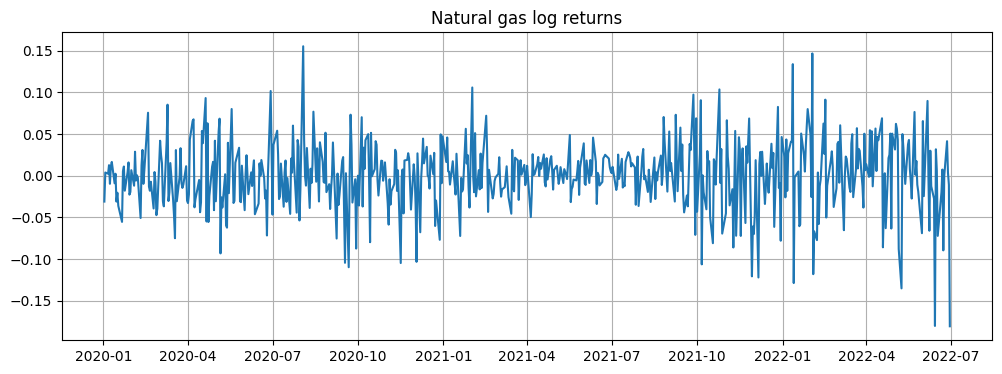

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(natural_gas.index, natural_gas['logret_1d'])
plt.title('Natural gas log returns')
plt.grid(True)
plt.show()

### 3.1 Base features (what you had + extras)
<p> In this section we are extracting the extra base cols for wti </p>


In [9]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
natural_gas[base_cols].tail()

,logret_1d,ret_5d,ret_10d,ret_20d,ret_60d,vol_20d,vol_60d,parkinson_20d,garman_klass_20d,vol_of_vol_20d,...,atr_14,adx_14,dd_from_60d_high,runup_from_60d_low,days_since_60d_high,trend_tstat_10,trend_tstat_20,trend_tstat_60,trend_tstat_best,trend_H_best
date,,,,,,,,,,,,,,,,,,,,,
2022-06-24,-0.000320,-0.174602,-0.357616,-0.360957,0.130671,0.058524,0.052828,0.057236,0.056183,0.007038,...,0.000378,26.186247,-0.327591,0.083679,13.0,-6.525403,-6.084316,4.481490,-6.525403,10.0
2022-06-27,0.041326,-0.061063,-0.303602,-0.308675,0.121688,0.060007,0.052702,0.057047,0.055382,0.007262,...,0.000373,26.763738,-0.299221,0.121997,14.0,-4.913552,-6.541973,3.605384,-6.541973,20.0
2022-06-28,0.003659,-0.037626,-0.272334,-0.285949,0.118769,0.060149,0.052699,0.056625,0.054751,0.007454,...,0.000360,26.970030,-0.296652,0.112307,15.0,-4.411730,-7.022739,2.812396,-7.022739,20.0
2022-06-29,-0.011019,-0.055962,-0.103097,-0.227950,0.094019,0.058754,0.052703,0.055886,0.054921,0.007571,...,0.000352,26.936075,-0.304360,0.100117,16.0,-4.071191,-8.725682,2.051639,-8.725682,20.0
2022-06-30,-0.180659,-0.147013,-0.315383,-0.474066,-0.085242,0.067005,0.057716,0.061693,0.058773,0.008185,...,0.000378,28.082757,-0.419335,0.000000,17.0,-3.981972,-9.932292,1.008587,-9.932292,20.0


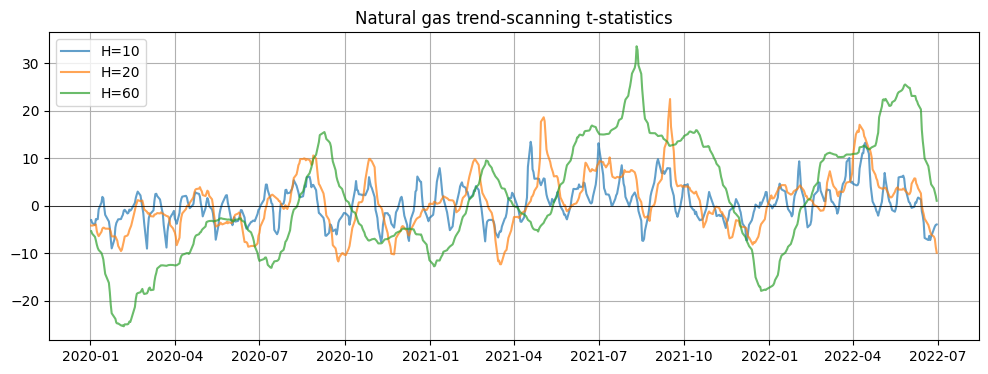

In [11]:
# Trend scanning t-stats — Lecture 1, max-|t| over multiple horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(natural_gas.index, natural_gas[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Natural gas trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

In [12]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
natural_gas[energy_cols].tail()

,energy_basket_ret_5d,energy_basket_vol_20d,rel_ret_vs_basket_5d,corr_to_basket_60d,crack_321_proxy,crack_321_z_60d,ho_cl_spread,rb_cl_spread,month_sin,month_cos,dow_sin,dow_cos,winter_indicator,driving_season
date,,,,,,,,,,,,,,
2022-06-24,-0.076530,0.031862,-0.098071,0.698289,-0.007808,-0.653094,-2.152614,-1.151036,1.224647e-16,-1.0,-0.951057,0.309017,0.0,1.0
2022-06-27,-0.014179,0.032228,-0.046884,0.690462,-0.035379,-2.143010,-2.200607,-1.180108,1.224647e-16,-1.0,0.000000,1.000000,0.0,1.0
2022-06-28,-0.001454,0.032284,-0.036172,0.706217,-0.001817,-0.235772,-2.221490,-1.172391,1.224647e-16,-1.0,0.951057,0.309017,0.0,1.0
2022-06-29,-0.025822,0.032777,-0.030140,0.702401,-0.016514,-1.046729,-2.242871,-1.186471,1.224647e-16,-1.0,0.587785,-0.809017,0.0,1.0
2022-06-30,-0.065902,0.034846,-0.081111,0.752785,-0.007818,-0.562919,-2.237879,-1.200694,1.224647e-16,-1.0,-0.587785,-0.809017,0.0,1.0


In [13]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available — subsequent OVX cells will be skipped.')

OVX rows: 4789 range: 2007-05-10 → 2026-05-21


In [15]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is std of daily logret — annualise by sqrt(252) and ×100 for vol points.
    rv_pts = natural_gas['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    wti = natural_gas.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(wti[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

            ovx_close     ovx_z  iv_rv_ratio  ovx_slope
date                                                   
2022-06-24  46.990002 -0.948578     0.505789   0.015561
2022-06-27  46.990002 -0.974712     0.493295  -0.044724
2022-06-28  46.590000 -1.102164     0.487936   0.000644
2022-06-29  48.570000 -0.590286     0.520751  -0.008573
2022-06-30  48.900002 -0.479887     0.459732   0.006587


In [17]:
# In this section we are adding the latent cols, hmms and gmm basket the reason behing the variables has been explained in the heating oil model section
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
natural_gas[latent_cols].tail()

,gmm_resp_low_vol,gmm_resp_med_vol,gmm_resp_high_vol,gmm_max_resp,hmm_filt_calm,hmm_filt_turbulent,hmm_next_turbulent,hmm_regime_age,hmm_basket_turbulent_energy,kmeans_cluster_id,kmeans_cluster_size
date,,,,,,,,,,,
2022-06-24,1.891139e-05,0.687033,0.312948,1.0,1.548386e-13,1.0,0.985107,34.0,0.999921,1.0,0.50
2022-06-27,1.550421e-05,0.572637,0.427347,1.0,5.610418e-15,1.0,0.985107,35.0,0.999909,1.0,0.25
2022-06-28,1.487599e-05,0.526964,0.473021,1.0,1.789536e-14,1.0,0.985107,36.0,0.999930,1.0,0.25
2022-06-29,2.220403e-05,0.576409,0.423569,1.0,1.041690e-13,1.0,0.985107,37.0,0.999981,1.0,0.25
2022-06-30,1.276564e-07,0.098116,0.901884,2.0,4.214644e-30,1.0,0.985107,38.0,1.000000,1.0,0.50


In [19]:
# In this section we are adding the primary signals to the heating oil model
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak', 'primary_signal_agreement_5d',
]
natural_gas[sig_cols].dropna().head(10)

,primary_signal,primary_signal_lag1,primary_signal_lag5,primary_signal_streak,primary_signal_agreement_5d
date,,,,,
2020-01-09,0.0,0.0,1.0,5.0,0.4
2020-01-10,1.0,0.0,1.0,6.0,0.4
2020-01-13,-1.0,1.0,1.0,0.0,0.0
2020-01-14,0.0,-1.0,0.0,1.0,0.0
2020-01-15,1.0,0.0,0.0,0.0,0.2
2020-01-16,0.0,1.0,0.0,1.0,0.2
2020-01-17,0.0,0.0,1.0,2.0,0.0
2020-01-21,-1.0,0.0,0.0,0.0,0.0
2020-01-22,0.0,-1.0,1.0,1.0,-0.2


In [21]:
SIGNAL_START = '2021-08-16'

# Pick the feature set you want to feed the downstream HMM.
# Start with the base + energy domain set; you can extend with latent/signal cols.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in §4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in natural_gas.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

X = natural_gas[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape)

train: (408, 20) test: (221, 20)


In [22]:
# In this section we are doing the PCA analysis to cluster the different features obtained
scaler = StandardScaler()
X_train_wti = scaler.fit_transform(X_train)
X_test_wti  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_wti)
X_test_pca  = pca.transform(X_test_wti)

pc_cols = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index, columns=pc_cols)
test_pca_df  = pd.DataFrame(X_test_pca,  index=X_test.index,  columns=pc_cols)

var = pd.DataFrame({
    'PC': pc_cols,
    'ratio': pca.explained_variance_ratio_,
    'cumulative': np.cumsum(pca.explained_variance_ratio_),
})
print('PCs kept:', pca.n_components_)

PCs kept: 12


In [23]:
# In this section we are running a BIC sweep to choose the most optimal number of states and obtain the probabilities of each state.

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

K=2: BIC=13,607.8
K=3: BIC=13,013.4
K=4: BIC=12,606.4
K=5: BIC=12,397.6
Chosen K = 5


In [24]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,hmm_filt_0,hmm_filt_1,hmm_filt_2,hmm_filt_3,hmm_filt_4
date,,,,,,,,,,,,,,,,,
2020-01-02,-2.348976,-2.248250,-1.427827,-0.269304,0.271381,0.120096,-0.237341,-0.597867,-0.671780,0.610332,-0.172621,0.260234,6.147982e-308,8.681182e-126,7.801277e-143,1.000000,1.693524e-199
2020-01-03,-2.283963,-2.320798,-1.288802,-0.570101,-0.733042,-0.435177,0.256366,-0.142033,0.327680,0.797605,0.028532,-0.075927,1.407789e-207,1.632901e-49,2.825321e-05,0.999972,4.689007e-44
2020-01-06,-2.082808,-2.253848,-1.513562,-0.602741,-0.702391,-0.239857,0.233254,-0.135952,0.133387,0.542712,-0.067345,0.036450,4.443226e-52,1.631938e-10,1.625753e-05,0.999984,9.768628e-09
2020-01-07,-1.434575,-1.914178,-1.992414,-0.559143,-0.637563,-0.030810,0.111103,0.054484,0.069277,0.600688,-0.128101,0.039902,1.035834e-16,2.605415e-10,1.742146e-05,0.999983,8.837422e-09
2020-01-08,-1.521391,-2.049075,-1.920089,-0.136329,0.460946,0.495239,-0.746197,-0.123245,-0.533397,0.793175,-0.232235,-0.046126,1.875494e-17,6.868204e-12,3.539212e-06,0.999996,1.174015e-09


In [26]:
# In this section we are performing the tripple barrier labeling for heating_oil prices
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
wti_close = (
    ohlcv[ohlcv['instrument'] == 'cl1s']
    .set_index('date')['close']
    .sort_index()
)

natural_gas_signals = natural_gas['primary_signal'].dropna()
natural_gas_labels = triple_barrier_meta_labels(wti_close, natural_gas_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(natural_gas_labels), 'win rate:', natural_gas_labels['meta_label'].mean().round(3))
natural_gas_labels.head()

labels: 373 win rate: 0.466


,exit,sigma_at_entry,primary_signal,first_touch,meta_label
entry,,,,,
2020-01-02,2020-01-03,0.011457,1.0,pt,1
2020-01-03,2020-01-08,0.013842,1.0,sl,0
2020-01-06,2020-01-08,0.013170,1.0,sl,0
2020-01-10,2020-01-22,0.018609,1.0,sl,0
2020-01-13,2020-01-23,0.018185,-1.0,pt,1


In [37]:
# Align X with labels — same pattern as your notebook
y_train = natural_gas_labels.loc[natural_gas_labels.index <  SIGNAL_START, 'meta_label']
y_test  = natural_gas_labels.loc[natural_gas_labels.index >= SIGNAL_START, 'meta_label']

X_train_natural_gas = train_pca_df.reindex(y_train.index).dropna()
X_test_natural_gas  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_wti.index]
y_test  = y_test.loc[X_test_wti.index]

print(X_train_natural_gas.shape, y_train.shape)
print(X_test_natural_gas.shape,  y_test.shape)

(246, 17) (246,)
(127, 17) (127,)


In [38]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


In [39]:
# In this section we are developing the logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_wti, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

    C penalty class_weight  mean_auc  std_auc
 0.10      l1         None  0.495983 0.074130
 0.01      l2         None  0.495206 0.087239
 1.00      l1         None  0.476277 0.082479
 0.10      l2         None  0.473223 0.078266
 0.10      l2     balanced  0.473223 0.078266
 1.00      l2         None  0.469896 0.080881
 1.00      l2     balanced  0.469419 0.081101
10.00      l2         None  0.469135 0.079361


In [40]:
# -----------------------------------------------------------------------
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.
# -----------------------------------------------------------------------
rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 1, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

 n_estimators  max_depth  min_samples_leaf  mean_auc  std_auc
          100          5                 5  0.551062 0.060928
          200          5                10  0.547078 0.056132
          200          8                10  0.546980 0.054513
          200          1                20  0.545842 0.084789
          200          5                10  0.545450 0.054922
          100          8                 5  0.543522 0.061563
          100          3                 5  0.541013 0.056082
          200          5                 5  0.535928 0.076253


In [43]:
# In this section is the XGB boost model we will be trying multiple different parameters and try to obtain the best one.
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_natural_gas, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

scale_pos_weight = 1.28  (n_neg=138, n_pos=108)
 n_estimators  learning_rate  max_depth  subsample  scale_pos_weight  mean_auc  std_auc
          100           0.05          5        0.8          1.000000  0.531772 0.044948
          200           0.05          5        0.8          1.000000  0.531755 0.048845
          200           0.05          5        0.8          1.277778  0.529301 0.038079
          200           0.05          3        0.8          1.000000  0.528282 0.071956
          200           0.05          3        0.8          1.277778  0.527947 0.062076
          100           0.10          3        0.8          1.000000  0.525345 0.054456
          100           0.05          3        0.8          1.000000  0.523660 0.058769
          100           0.10          5        0.7          1.000000  0.523300 0.079783


In [41]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_natural_gas, y_train)
    proba = model.predict_proba(X_test_wti)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

LR  test AUC: 0.4324
RF  test AUC: 0.5045
XGB  test AUC: 0.5035


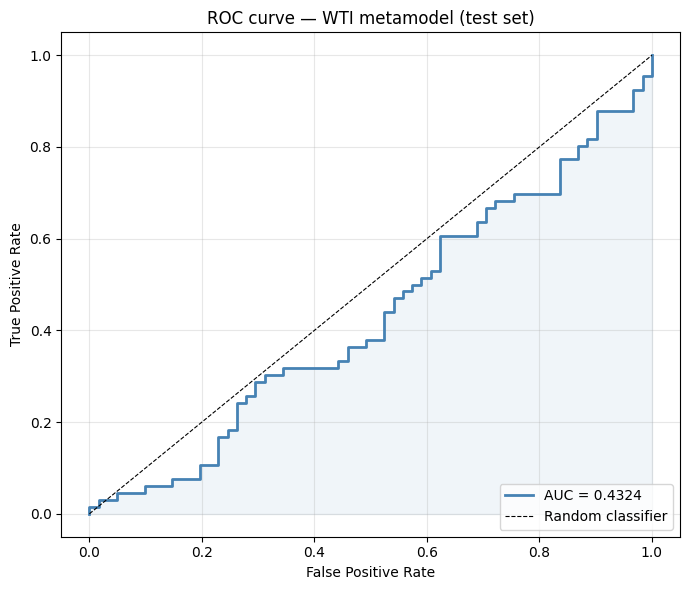

Test AUC: 0.4324


In [44]:

best_model = best_lr  # swap to best_lr or best_rf if needed

proba = best_model.predict_proba(X_test_wti)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve — WTI metamodel (test set)')

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc:.4f}')

In [45]:
scaler_nn = StandardScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_natural_gas.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_natural_gas.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


input_dim=17, pos_weight=1.28


In [47]:
# In this section of the code we will be running the neural networks

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [48]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.4329 std=0.0912
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.4975 std=0.0596
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5179 std=0.0328
hidden=128 dropout=0.3 lr=0.001  mean_auc=0.5122 std=0.0517
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.4837 std=0.0617
hidden=128 dropout=0.4 lr=0.0005  mean_auc=0.5474 std=0.0472

Best MLP: {'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.0005}


In [49]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have ~70 features
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.5102 std=0.0759
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5708 std=0.0526
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5762 std=0.0188
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.5274 std=0.0662
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5812 std=0.0881

Best VSN: {'hidden_dim': 64, 'dropout': 0.4, 'lr': 0.0005}


In [50]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_wti.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_wti, X_test_wti]).values),
    index=pd.concat([X_train_wti, X_test_wti]).index,
    columns=X_train_wti.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.4988 std=0.0988
seq=10 hidden=64 layers=2  mean_auc=0.5745 std=0.0645
seq=20 hidden=32 layers=1  mean_auc=0.5117 std=0.1042
seq=20 hidden=64 layers=2  mean_auc=0.5405 std=0.0550
seq=20 hidden=64 layers=2  mean_auc=0.5166 std=0.0916
seq=60 hidden=64 layers=2  mean_auc=0.5247 std=0.0833

Best LSTM: {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}


In [51]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.4354
VSN  test AUC: 0.4685
LSTM test AUC: 0.5579


In [52]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_wti)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_wti)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_wti)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [53]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades), # Total number of trades due to labeling
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4), # The amount of trades taken
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       127      100.0     0.5197  1.0000 0.6839 0.4324
      0.35       127      100.0     0.5197  1.0000 0.6839 0.4324
      0.40       126       99.2     0.5159  0.9848 0.6771 0.4324
      0.45       105       82.7     0.4952  0.7879 0.6082 0.4324
      0.50        16       12.6     0.3125  0.0758 0.1220 0.4324

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       126       99.2     0.5159  0.9848 0.6771 0.5045
      0.35       121       95.3     0.5041  0.9242 0.6524 0.5045
      0.40       113       89.0     0.5221  0.8939 0.6592 0.5045
      0.45        84       66.1     0.5119  0.6515 0.5733 0.5045
      0.50        52       40.9     0.5192  0.4091 0.4576 0.5045
      0.55        28       22.0     0.6071  0.2576 0.3617 0.5045
      0.60         7        5.5     0.4286  0.0455 0.0822 0.5045
      0.65         1        0.8     1.0000  0.0152 0.0

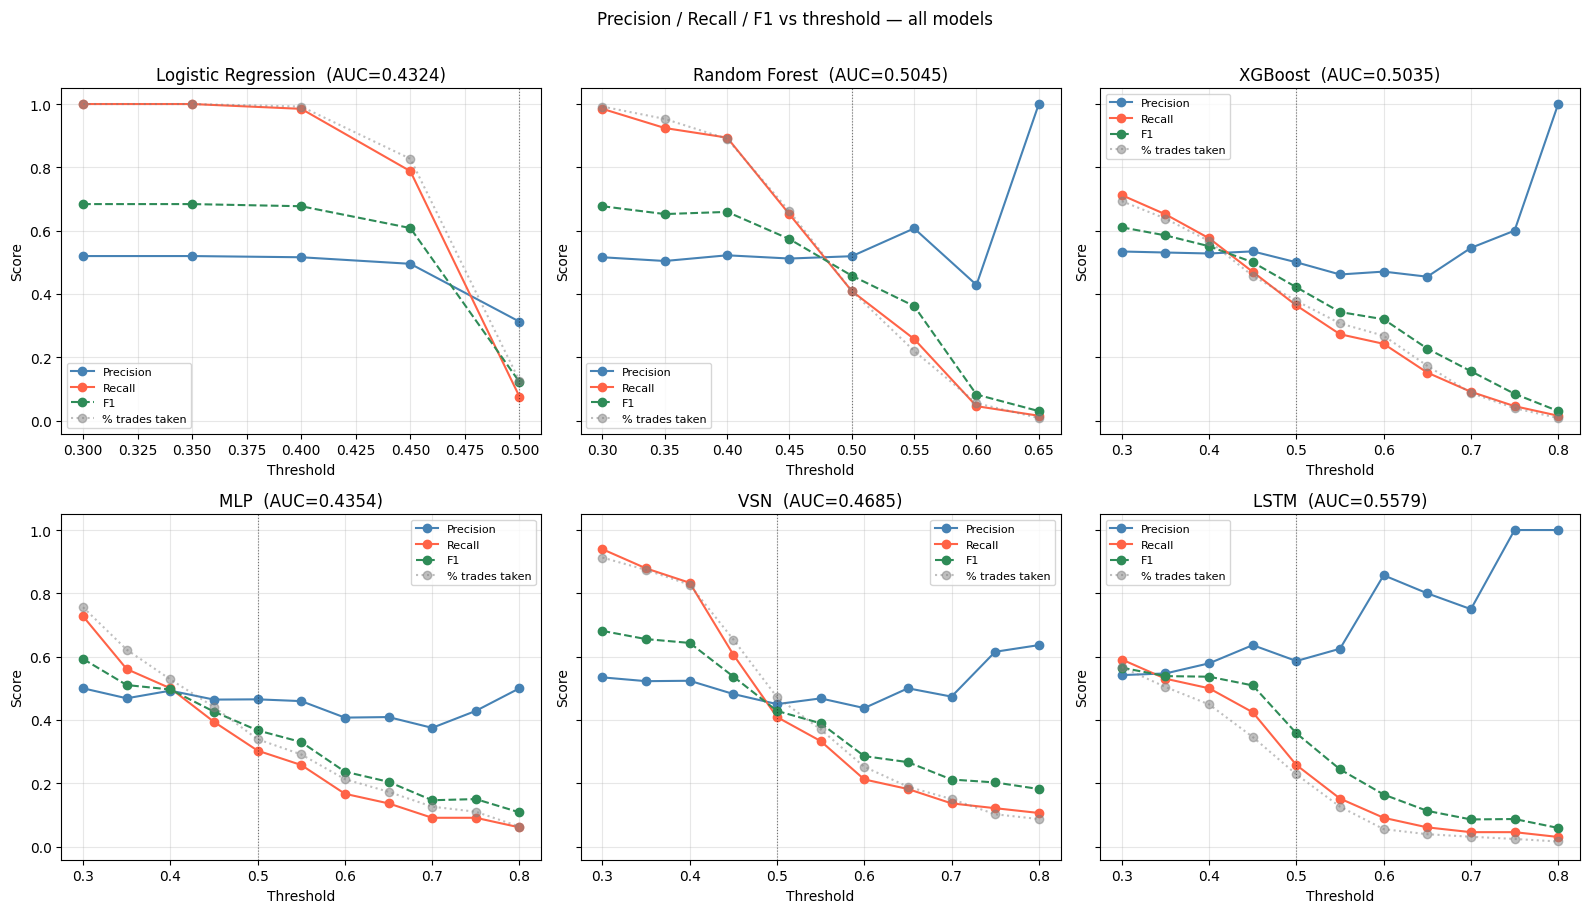

In [54]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold — all models', y=1.01)
plt.tight_layout()
plt.show()